In [1]:

from langgraph.graph import StateGraph, START, END
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage, HumanMessage
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph.message import add_messages
from dotenv import load_dotenv

from langgraph.prebuilt import ToolNode, tools_condition
from langchain_tavily import TavilySearch
from langchain_core.tools import tool
from typing import Any
import requests
import math
import os

In [2]:
load_dotenv()

True

In [4]:
llm = ChatGoogleGenerativeAI(
    model="gemini-2.5-flash",
    temperature=0.7,
)

## Tools

In [ ]:
# search tool
search_tool = TavilySearch(
    max_results=5,
    topic="general",
    search_depth="advanced"
)
  
# import os
import requests
from langchain_core.tools import tool

WEATHERSTACK_API_KEY = os.getenv("WEATHERSTACK_API_KEY")

@tool
def get_weather(city: str) -> str:
    """Ambil informasi cuaca terkini untuk sebuah kota menggunakan Weatherstack API.
    
    Args:
        city: Nama kota, misalnya 'Jakarta' atau 'Bandung'
    """
    url = "http://api.weatherstack.com/current"
    params = {
        "access_key": WEATHERSTACK_API_KEY,
        "query": city,
    }
    
    response = requests.get(url, params=params)
    data = response.json()
    
    if "error" in data:
        return f"Error: {data['error'].get('info', 'Gagal mengambil data cuaca')}"
    
    location = data["location"]["name"]
    country = data["location"]["country"]
    temp = data["current"]["temperature"]
    desc = data["current"]["weather_descriptions"][0]
    humidity = data["current"]["humidity"]
    
    return (
        f"Cuaca di {location}, {country}: {desc}, "
        f"suhu {temp}°C, kelembapan {humidity}%"
    )

In [8]:
tools = [search_tool, get_weather]

llm_with_tools = llm.bind_tools(tools)

In [ ]:
# state
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [10]:
# graph nodes
def chat_node(state: ChatState):
    """LLM node that may answer or request a tool call."""
    messages = state['messages']
    response = llm_with_tools.invoke(messages)
    return {"messages": [response]}

tool_node = ToolNode(tools)  # Executes tool calls

## Graph

In [11]:
# graph structure
graph = StateGraph(ChatState)

# add nodes to the graph
graph.add_node("chat_node", chat_node)
graph.add_node("tools", tool_node)

In [12]:
# add edges to the graph
graph.add_edge(START, "chat_node")
# If the LLM asked for a tool, go to ToolNode; else finish
graph.add_conditional_edges("chat_node", tools_condition)

graph.add_edge("tools", "chat_node") 

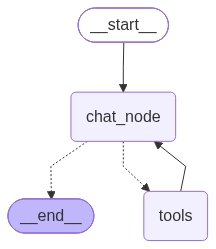

In [13]:
chat_bot = graph.compile()
chat_bot

In [14]:
initial_state= {
    "messages": [HumanMessage(content="Berita terbaru di indonesia dan kondisi cuaca di jakarta hari ini")]}

res = chat_bot.invoke(initial_state)

In [15]:
res

{'messages': [HumanMessage(content='Berita terbaru di indonesia dan kondisi cuaca di jakarta hari ini', additional_kwargs={}, response_metadata={}, id='beb08e21-df7d-4da0-954b-df769a97cb0c'),
  AIMessage(content='', additional_kwargs={'function_call': {'name': 'get_weather', 'arguments': '{"city": "Jakarta"}'}, '__gemini_function_call_thought_signatures__': {'aa210b2a-071a-4af8-b648-c5beaebbc3d4': 'CtwEARFNMg/jYJZkmvq803pdDEpxcMH4UqPpZ1VvMXX0p2W9ST/pAaWPLbfAkuzm5U5Pj1HiORepw0chqfYzwPP4gPNBVhSrkae/kRsIQvZuHR8ihoaZi8AypMHWzBguJ3ZTHTAY2QKDto1rYJ5LrOKyC2nTC/JA8Hc8iWz26ogat1pfTxemAEfiL2T3H2Ws0QzwIRfwuDBK1BFDoFcuRxAjE/UIyqHWd40SorMevkomxRmQJBXr5agazfDnqAzxb0R2pYKNwJyAszFW4g1B3gL+TnEMZxsmYMUeK4oVqR0z5qI288YV2QUzQfzResOdei3c1DU+9JdZk4DLCrtLhVwPg8RE3PF0sUVBcqhHf03Oe5lmlCVjXEJ/qwtKsxx1aLAyUJe128jrD+OjP1aGn1InsOdYjCzgIly1LaUm0Kx9PILSpq3Y9Q85O0vlqtiBazqqpcvNnwQ6zJursXmkH/2HXkvuKHvvo/FkgJTiJA2T4tBkWe3wE+ySj6eNXpfF93XcT3bo7ZrajEaMNOoE0/EzFUQgqK5KDJsSz2IEqc1k6YmaUdVLsgwrLVhRcKlTmEMX4WKq7GKPE7vPQ/IZqi

In [19]:
print(res['messages'][-1].content[0]["text"])

Berikut adalah berita terbaru di Indonesia dan kondisi cuaca di Jakarta hari ini:

**Berita Terbaru di Indonesia:**
*   Kabut asap dari kebakaran hutan menyebabkan lonjakan infeksi pernapasan.
*   Anak-anak di Jakarta kesulitan bermain di luar karena suhu yang sangat panas dan kurangnya tempat teduh.
*   Petani di Jawa Tengah menghadapi masalah tikus dan kekeringan.
*   Penurunan harga Pertamax dan BBM nonsubsidi lainnya telah diumumkan oleh Pertamina.
*   Aksi unjuk rasa mengenai berbagai isu seperti pajak, pendidikan, upah, dan korupsi akan diadakan di depan Gedung DPR/MPR RI di Jakarta.

**Kondisi Cuaca di Jakarta:**
*   Cuaca di Jakarta: Kabut asap, suhu 27°C, kelembapan 68%.
